### DEM Derivatives
Calcul de toutes les couches terrain dérivées depuis le DEM local (`data/mono_dem.tif`).

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("."))  # rend durpy et derivedDem importables
#sys.path.insert(0, r"D:\REPOSITORY\FloodRM")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from durpy.derivedDem import (
    init_local_engine,
    derive_slope,
    derive_aspect,
    derive_curvature,
    derive_twi,
    derive_flow_accumulation,
    derive_drainage_density,
    derive_dist_to_river,
    load_rain,
    load_lulc,
)

from durpy.variables import WC_LEGEND

DEM_PATH = "data/mono_dem.tif"
init_local_engine(DEM_PATH)

DEM chargé : (11010, 4500) | ext=[0.687639184, 1.937639284, 6.279305658, 9.337639236]


In [2]:
slope,  ext = derive_slope()
aspect, ext = derive_aspect()
curv,   ext = derive_curvature()
twi,    ext = derive_twi()
facc,   ext = derive_flow_accumulation()
density, ext = derive_drainage_density()
distRiver, ext = derive_dist_to_river()

🗺️  raster enregistré : .\_tmp_dem_pysheds.tif


In [4]:
lulc, ext = load_lulc("data/lulc_esa.tif")
rain, ext = load_rain("data/chirps_daily_1985_2023.nc")

Pluie annuelle moyenne chargee : min=0.0 mm/an | max=1712.5 mm/an


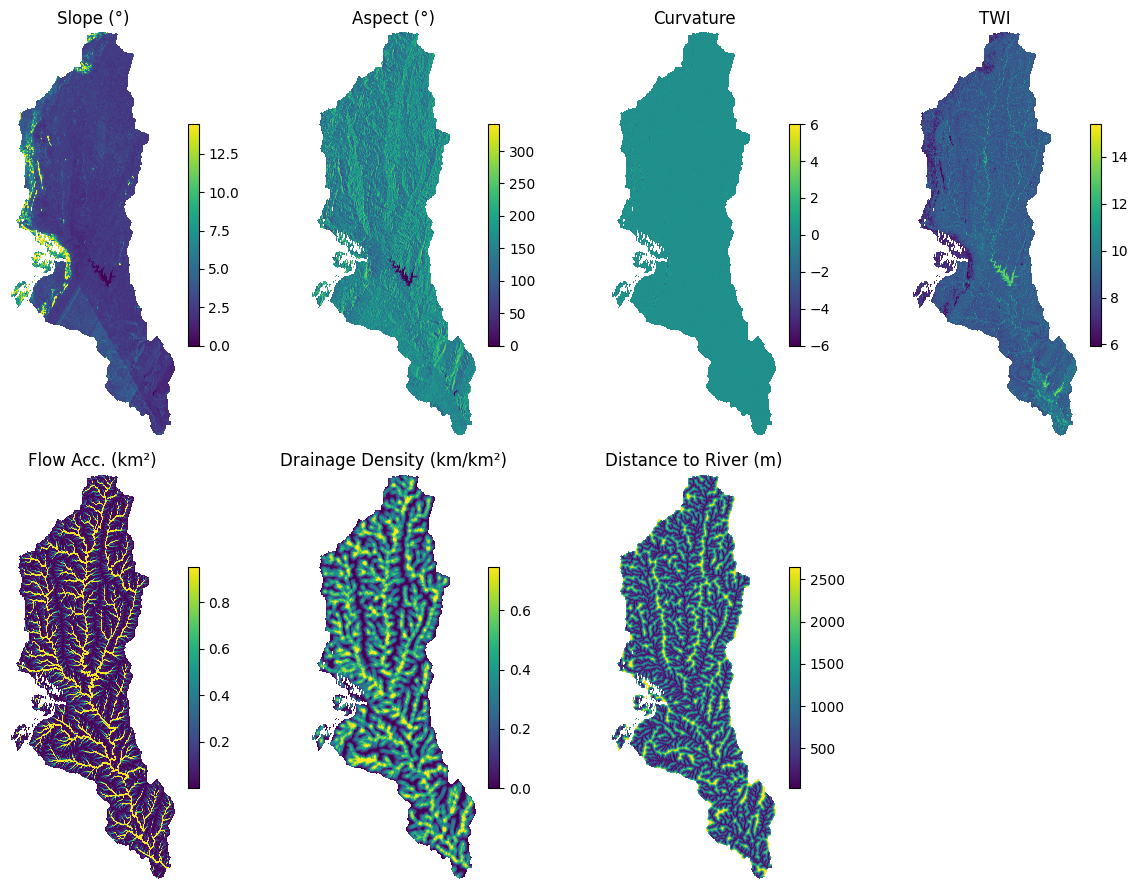

In [3]:
layers = {
    "Slope (°)":       slope,
    "Aspect (°)":      aspect,
    "Curvature":       curv,
    "TWI":             twi,
    "Flow Acc. (km²)": facc,
    "Drainage Density (km/km²)": density,
    "Distance to River (m)": distRiver,
}

fig, axes = plt.subplots(2, 4, figsize=(12, 9))
for ax, (title, arr) in zip(axes.flat, layers.items()):
    im = ax.imshow(
        arr, cmap="viridis",
        vmin=np.nanpercentile(arr, 2),
        vmax=np.nanpercentile(arr, 98),
    )
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
lulc, ext = load_lulc("data/lulc_esa.tif")

codes  = sorted(WC_LEGEND.keys())
colors = [WC_LEGEND[c][1] for c in codes]
cmap   = ListedColormap(colors)
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(lulc, cmap=cmap, vmin=codes[0]-5, vmax=codes[-1]+5)
patches = [Patch(color=WC_LEGEND[c][1], label=WC_LEGEND[c][0]) for c in codes]
#ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
#ax.set_title("Land Use / Land Cover"); ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# --- Chargement de la pluie annuelle moyenne (CHIRPS) ---
from durpy.derivedDem import load_rain

rain, ext = load_rain("data/chirps_daily_1985_2023.nc")

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(rain, cmap="YlGnBu",
               vmin=np.nanpercentile(rain, 2),
               vmax=np.nanpercentile(rain, 98))
ax.set_title("Pluie annuelle moyenne")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, label="mm/an")
plt.tight_layout()
plt.show()


### AHP for Flood Risk Mapping
Workflow complet : normalisation → reclassification → poids → FIPS → zones de risque.

In [5]:
from durpy.ahp import (
    normalize_all, compute_scores, compute_weights,
    compute_flood_index, classify_flood_index, sensitivity_analysis,
)
from durpy.ahp_config import RECLASS, AHP_CRITERIA, AHP_PAIRS, AHP_INCLUDE, NORM_KEYS
from durpy.variables import LAYERS, SCORE_LEGEND

In [6]:
# --- ETAPE 1 : Normalisation 0-1 ---
# Methodes disponibles : minmax | robust | zscore | fuzzy_linear | fuzzy_sigmoidal
NORM_METHOD = "minmax"

print("Normalisation des couches :", NORM_KEYS)
stats_df = normalize_all(NORM_KEYS, method=NORM_METHOD)
print("Statistiques :")
print(stats_df.to_string(index=False))


Normalisation des couches : ['elevation', 'slope', 'curvature', 'dist_to_river', 'drainage_density', 'twi', 'flow_accumulation', 'rain_mm_yr']
  ✓ norm_elevation
  ✓ norm_slope
  ✓ norm_curvature
  ✓ norm_dist_to_river
  ✓ norm_drainage_density
  ✓ norm_twi
  ✓ norm_flow_accumulation
  ✓ norm_rain_mm_yr
Statistiques :
        criterion       min        max     mean      std method
        elevation  -33.0000   993.0000 261.2402 146.1052 minmax
            slope    0.0000    63.9490   3.3326   3.3070 minmax
        curvature -180.0000   150.0000   0.0006   3.0426 minmax
    dist_to_river    0.0000  5629.6191 973.5883 713.8777 minmax
 drainage_density   -0.0000     1.1781   0.2921   0.2162 minmax
              twi   -1.4021    27.3493   8.6254   2.3516 minmax
flow_accumulation    0.0010 23331.1719   7.6257 323.9386 minmax
       rain_mm_yr    0.0000  1712.4866 917.1321 551.2990 minmax


In [ ]:
# --- ETAPE 2 : Reclassification -> scores 1-5 ---
# RECLASS_INPUT = "raw"       -> utilise les couches brutes
# RECLASS_INPUT = "normalized" -> utilise les couches normalisees
RECLASS_INPUT = "raw"
use_norm = RECLASS_INPUT == "normalized"

print("Reclassification des facteurs :")
SCORES = compute_scores(RECLASS, AHP_INCLUDE, use_norm=use_norm)
print(f"{len(SCORES)} facteurs scores : {list(SCORES.keys())}")


In [7]:
# --- ETAPE 3 : Poids AHP (matrice de Saaty) ---
# Si CR > 0.10 : ajuster AHP_PAIRS dans durpy/ahp_config.py
weights = compute_weights(AHP_PAIRS, AHP_CRITERIA, AHP_INCLUDE, SCORES)


Critères actifs (8) : elevation, slope, aspect, curvature, dist_to_river, drainage_density, twi, flow_accumulation
λ_max = 8.124 | CI = 0.0176 | RI = 1.41 | CR = 0.0125 → ✅ consistant (CR < 0.10)
 rank         criterion  weight_eigenvector  weight_RGMM  weight_%
    1               twi              0.2143       0.2153     21.43
    2 flow_accumulation              0.1965       0.1975     19.65
    3     dist_to_river              0.1912       0.1913     19.12
    4             slope              0.1447       0.1435     14.47
    5         elevation              0.1156       0.1157     11.56
    6  drainage_density              0.0777       0.0766      7.77
    7         curvature              0.0387       0.0387      3.87
    8            aspect              0.0213       0.0213      2.13


In [8]:
# --- ETAPE 4 : Indice de risque (FIPS) ---
fips = compute_flood_index(SCORES, weights)
print(f"FIPS : min={float(np.nanmin(fips)):.3f} | max={float(np.nanmax(fips)):.3f} | mean={float(np.nanmean(fips)):.3f}")


FIPS : min=0.795 | max=5.000 | mean=2.807


In [9]:
# --- ETAPE 5 : Classification en zones de risque ---
# method = "equal" (seuils fixes 1.8/2.6/3.4/4.2) ou "quantile"
zones, breaks = classify_flood_index(fips, method="equal")
LAYERS["flood_risk"] = zones


Seuils zones : [1.8, 2.6, 3.4, 4.2]


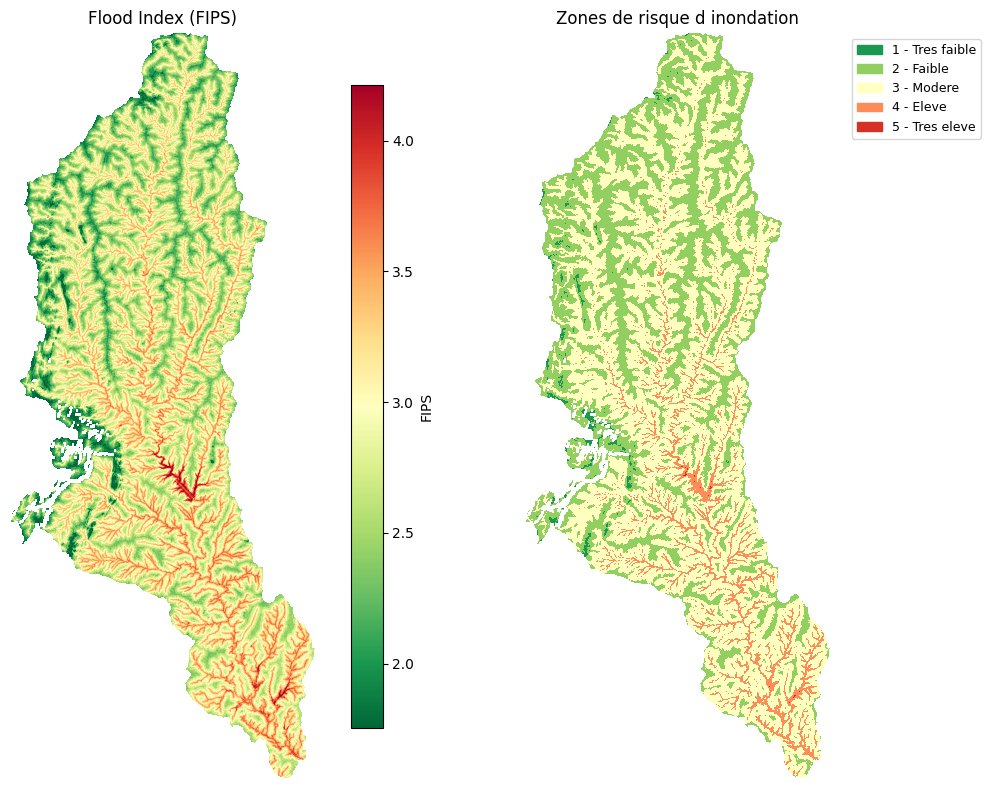

In [ ]:
# --- ETAPE 6 : Visualisation FIPS + zones ---
zone_colors = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
zone_labels = ["1 - Tres faible", "2 - Faible", "3 - Modere", "4 - Eleve", "5 - Tres eleve"]
cmap_zones = ListedColormap(zone_colors)
cmap_zones.set_bad(alpha=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# FIPS continu
im0 = axes[0].imshow(fips, cmap="RdYlGn_r", vmin=np.nanpercentile(fips, 2),
                     vmax=np.nanpercentile(fips, 98))
axes[0].set_title("Flood Index (FIPS)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="FIPS")

# Zones discretes
im1 = axes[1].imshow(zones, cmap=cmap_zones, vmin=0.5, vmax=5.5)
axes[1].set_title("Zones de risque d inondation")
axes[1].axis("off")
patches = [Patch(color=zone_colors[i], label=zone_labels[i]) for i in range(5)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :
 rank         criterion  weight_%  MAD_FIPS
    1 flow_accumulation     19.65    0.2795
    2             slope     14.47    0.2305
    3     dist_to_river     19.12    0.1869
    4               twi     21.43    0.1574
    5         elevation     11.56    0.1394
    6  drainage_density      7.77    0.0848
    7         curvature      3.87    0.0558
    8            aspect      2.13    0.0283


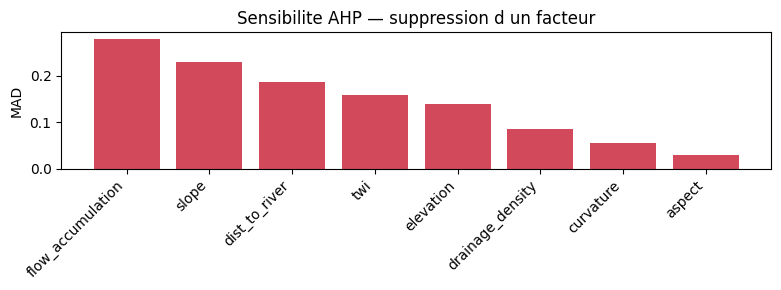

In [11]:
# --- ETAPE 7 : Analyse de sensibilite ---
sens_df = sensitivity_analysis(SCORES, weights, fips)
print("Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :")
print(sens_df.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.bar(sens_df["criterion"], sens_df["MAD_FIPS"], color="#d1495b")
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAD")
plt.title("Sensibilite AHP — suppression d un facteur")
plt.tight_layout()
plt.show()
